#  Generalized Tree Crown Classification Pipeline
### Unsupervised Feature Clustering → Visual Labelling → Validation → Google Earth Export

**Four steps — run Steps 1 and 2 sequentially. Steps 3 and 4 are independent:**

| Step | Input | Output | Required? |
|------|-------|--------|-----------|
| **Step 1** | Orthomosaics + Crown GeoJSONs | Crop TIFFs, DINOv2 embeddings, cluster folders, k-selection plots | ✅ Yes |
| **Step 2** | Filled cluster_species_map.csv | polygon_species.csv (original IDs), species folders | ✅ Yes |
| **Step 3** | Ground truth CSV (user-provided) | Confusion matrix, accuracy, kappa, F1 | ⚪ Optional |
| **Step 4** | polygon_species.csv + GeoJSONs | KMZ for Google Earth | ✅ Yes |

> **Step 3 is independent** — you can run Step 4 directly after Step 2 without running Step 3.

> **Requirements:** `pip install torch torchvision timm rasterio geopandas shapely tqdm scikit-learn matplotlib seaborn pandas numpy simplekml Pillow`


---
##  Shared Utilities — Run This Cell First
Imports, helpers, and device setup shared by all three steps.


In [1]:
import os, re, shutil, json, zipfile, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask as rio_mask
from tqdm import tqdm
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import timm
import simplekml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, classification_report,
    silhouette_score, davies_bouldin_score
)
from sklearn.manifold import TSNE
warnings.filterwarnings('ignore')

# ── Device ────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')

# ── Helpers ───────────────────────────────────────────────────────
def make_dirs(*paths):
    for p in paths: os.makedirs(p, exist_ok=True)

def crown_id_from_gdf(gdf):
    """Return a Series of integer crown IDs from whichever column exists."""
    for col in ['crown_id', 'id']:
        if col in gdf.columns:
            return gdf[col].astype(int)
    return pd.Series(gdf.index.astype(int))

def auto_detect_csv_columns(df):
    """
    Detect (filename_col, label_col) from any CSV regardless of column names.
    Filename col = column whose values look like filenames (contain '.' or '_tree_').
    Label col    = column with fewest unique values (most likely the class column).
    """
    filename_col = label_col = None
    for col in df.columns:
        sample = df[col].dropna().astype(str)
        if sample.str.contains(r'\.(tif|tiff|jpg|png)', case=False).mean() > 0.5:
            filename_col = col
            break
    if filename_col is None:
        for col in df.columns:
            if df[col].dropna().astype(str).str.contains(r'_tree_', case=False).mean() > 0.3:
                filename_col = col
                break
    remaining = [c for c in df.columns if c != filename_col]
    if remaining:
        label_col = min(remaining, key=lambda c: df[c].nunique())
    return filename_col, label_col

def normalize_label(val):
    """Lowercase + strip + replace spaces with underscore."""
    return str(val).strip().lower().replace(' ', '_').replace('-', '_')

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})
print('✅ Shared utilities ready.')


Device : cpu
✅ Shared utilities ready.


---
# STEP 1 — Crop → Embed → Cluster → Select k

**Input:**  Orthomosaics folder + Crown polygon GeoJSONs folder  
**Output:**
- `crowns/` — individual crown TIFFs
- `features/` — DINOv2 embeddings (`.npy` + `.csv`)
- `clustering/k{n}/cluster_{i}/` — TIFF sorted by cluster for each k
- `clustering/tsne_k{n}.png` — t-SNE plot per k
- `clustering/k_selection.png` — Silhouette / Elbow / Davies-Bouldin
- `clustering/k_recommendation_table.csv` — ranked k table


### ⚙️ Step 1 — Configuration


In [ ]:
# STEP 1 — EDIT ONLY

# Folder containing orthomosaic GeoTIFFs (one or more .tif files)
S1_ORTHO_FOLDER   = '/Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/ortho'

# Folder containing crown polygon GeoJSONs (one per site)
S1_POLY_FOLDER    = '/Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/geojson'

# Root output folder for Step 1
S1_OUTPUT_ROOT    = '/Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step1_output'

# Range of k values to evaluate
S1_K_LIST         = [2, 4, 6, 8, 10, 12]

# DINOv2 model — options:
#   'vit_small_patch14_dinov2.lvd142m'  (faster, less memory)
#   'vit_base_patch14_dinov2.lvd142m'   (recommended)
#   'vit_large_patch14_dinov2.lvd142m'  (best quality, slow)
S1_MODEL_NAME     = 'vit_base_patch14_dinov2.lvd142m'

# Image size fed to DINOv2 (224 recommended)
S1_IMG_SIZE       = 224

# Batch size for feature extraction (reduce if OOM)
S1_BATCH_SIZE     = 32

# PCA components before clustering (None = skip PCA)
S1_PCA_COMPONENTS = 50

# Copy crop TIFFs into cluster folders? (True = easier inspection, uses more disk)
S1_COPY_TO_CLUSTER_FOLDERS = True

# ── Derived paths (do not edit) ───────────────────────────────────
S1_DIR_CROWNS   = os.path.join(S1_OUTPUT_ROOT, 'crowns')
S1_DIR_FEATURES = os.path.join(S1_OUTPUT_ROOT, 'features')
S1_DIR_CLUSTER  = os.path.join(S1_OUTPUT_ROOT, 'clustering')
make_dirs(S1_DIR_CROWNS, S1_DIR_FEATURES, S1_DIR_CLUSTER)

print('Step 1 config:')
print(f'  Ortho folder   : {S1_ORTHO_FOLDER}')
print(f'  Polygon folder : {S1_POLY_FOLDER}')
print(f'  Output root    : {S1_OUTPUT_ROOT}')
print(f'  k values       : {S1_K_LIST}')
print(f'  Model          : {S1_MODEL_NAME}')
print(f'  PCA components : {S1_PCA_COMPONENTS}')
print(' Config loaded.')


Step 1 config:
  Ortho folder   : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/ortho
  Polygon folder : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/geojson
  Output root    : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step1_output
  k values       : [2, 4, 6, 8, 10, 12]
  Model          : vit_base_patch14_dinov2.lvd142m
  PCA components : 50
✅ Config loaded.


### 1A — Crown Cropping


In [ ]:
print('STEP 1A: Crown cropping')

# Open all orthomosaics
ortho_srcs = []
for f in os.listdir(S1_ORTHO_FOLDER):
    if f.lower().endswith('.tif'):
        ortho_srcs.append(rasterio.open(os.path.join(S1_ORTHO_FOLDER, f)))
print(f'Orthomosaics found: {len(ortho_srcs)}')

total_saved = total_failed = 0

for gj_file in sorted(os.listdir(S1_POLY_FOLDER)):
    if not gj_file.endswith('.geojson'):
        continue

    prefix = os.path.splitext(gj_file)[0]
    gdf    = gpd.read_file(os.path.join(S1_POLY_FOLDER, gj_file))
    gdf['_cid'] = crown_id_from_gdf(gdf)
    gdf = gdf.sort_values('_cid').reset_index(drop=True)
    print(f'\n  {gj_file}  ({len(gdf)} crowns)')

    for _, row in tqdm(gdf.iterrows(), total=len(gdf), desc=prefix):
        cid      = int(row['_cid'])
        out_name = f'{prefix}_{cid:03d}.tif'
        out_path = os.path.join(S1_DIR_CROWNS, out_name)
        if os.path.exists(out_path):   # skip already cropped
            total_saved += 1
            continue
        geom   = [row.geometry]
        saved  = False
        for src in ortho_srcs:
            try:
                out_img, out_tf = rio_mask(src, geom, crop=True)
                meta = src.meta.copy()
                meta.update(height=out_img.shape[1],
                            width=out_img.shape[2],
                            transform=out_tf)
                with rasterio.open(out_path, 'w', **meta) as dst:
                    dst.write(out_img)
                saved = True
                break
            except Exception:
                continue
        if saved: total_saved += 1
        else:     total_failed += 1

for src in ortho_srcs: src.close()

print(f'\n Cropping complete — saved: {total_saved}  failed: {total_failed}')
print(f'   Crown TIFFs in: {S1_DIR_CROWNS}')


=== STEP 1A: Crown cropping ===
Orthomosaics found: 4

  s1_tree.geojson  (656 crowns)


s1_tree: 100%|██████████| 656/656 [00:04<00:00, 150.18it/s]



  s2_tree.geojson  (717 crowns)


s2_tree: 100%|██████████| 717/717 [00:03<00:00, 180.38it/s]



  s3_tree.geojson  (628 crowns)


s3_tree: 100%|██████████| 628/628 [00:03<00:00, 176.72it/s]



  s4_tree.geojson  (178 crowns)


s4_tree: 100%|██████████| 178/178 [00:01<00:00, 91.61it/s] 


✅ Cropping complete — saved: 2179  failed: 0
   Crown TIFFs in: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step1_output/crowns


### 1B — DINOv2 Feature Extraction


In [ ]:
print('=== STEP 1B: DINOv2 feature extraction ===')

feat_npy = os.path.join(S1_DIR_FEATURES, 'dinov2_features.npy')
feat_csv = os.path.join(S1_DIR_FEATURES, 'dinov2_features.csv')

if os.path.exists(feat_npy):
    print('  Cached features found — loading.')
    features   = np.load(feat_npy)
    names      = pd.read_csv(feat_csv)['image_name'].tolist()
else:
    tf = transforms.Compose([
        transforms.Resize((S1_IMG_SIZE, S1_IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.485,0.456,0.406),
                             std=(0.229,0.224,0.225)),
    ])
    model = timm.create_model(S1_MODEL_NAME, pretrained=True,
                              num_classes=0, img_size=S1_IMG_SIZE)
    model.eval().to(device)

    img_paths = sorted([os.path.join(S1_DIR_CROWNS, f)
                        for f in os.listdir(S1_DIR_CROWNS)
                        if f.lower().endswith('.tif')])
    print(f'  Images to process: {len(img_paths)}')

    features, names = [], []
    for i in tqdm(range(0, len(img_paths), S1_BATCH_SIZE), desc='Extracting'):
        batch_paths = img_paths[i:i+S1_BATCH_SIZE]
        imgs, nms   = [], []
        for p in batch_paths:
            try:
                img = Image.open(p).convert('RGB')
                imgs.append(tf(img))
                nms.append(os.path.basename(p))
            except Exception as e:
                print(f'  ⚠️ Skipped {p}: {e}')
        if not imgs: continue
        batch = torch.stack(imgs).to(device)
        with torch.no_grad():
            feat = model(batch)
        feat = F.normalize(feat, p=2, dim=1)
        features.append(feat.cpu().numpy())
        names.extend(nms)

    features = np.vstack(features)
    np.save(feat_npy, features)
    pd.DataFrame({'image_name': names}).to_csv(feat_csv, index=False)

print(f'  Feature matrix: {features.shape}')
print(f'  Images indexed: {len(names)}')

# ── Standardize + optional PCA ────────────────────────────────────
X = StandardScaler().fit_transform(features)
if S1_PCA_COMPONENTS and S1_PCA_COMPONENTS < X.shape[1]:
    X = PCA(n_components=S1_PCA_COMPONENTS, random_state=42).fit_transform(X)
    print(f'  PCA applied → shape: {X.shape}')
else:
    print(f'  PCA skipped — using raw standardized features')

names_df = pd.DataFrame({'image_name': names})
np.save(os.path.join(S1_DIR_FEATURES, 'X_reduced.npy'), X)
print(' Features ready.')


=== STEP 1B: DINOv2 feature extraction ===
  Images to process: 2179


Extracting: 100%|██████████| 69/69 [03:58<00:00,  3.46s/it]


  Feature matrix: (2179, 768)
  Images indexed: 2179
  PCA applied → shape: (2179, 50)
✅ Features ready.


### 1C — Multi-k Clustering + k-Selection Signals


In [ ]:
print(' STEP 1C: Multi-k clustering ')

inertia_vals = []
silhouette_vals = []
db_vals = []
all_cluster_labels = {}   # k → array of cluster assignments for all images

for k in S1_K_LIST:
    print(f'  k={k} ...', end=' ')
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cl = km.fit_predict(X)
    all_cluster_labels[k] = cl

    inertia_vals.append(km.inertia_)
    sil = silhouette_score(X, cl, sample_size=min(5000, len(X)), random_state=42)
    db  = davies_bouldin_score(X, cl)
    silhouette_vals.append(sil)
    db_vals.append(db)
    print(f'inertia={km.inertia_:.0f}  silhouette={sil:.4f}  davies_bouldin={db:.4f}')

    # ── Save cluster assignment CSV ───────────────────────────────
    cl_df = names_df.copy()
    cl_df['cluster'] = cl
    cl_df['cluster_label'] = cl_df['cluster'].apply(lambda x: f'cluster_{x}')
    cl_df.to_csv(os.path.join(S1_DIR_CLUSTER, f'k{k}_assignments.csv'), index=False)

    # ── Create cluster folders + copy TIFFs ──────────────────────
    k_dir = os.path.join(S1_DIR_CLUSTER, f'k{k}')
    for ci in range(k):
        os.makedirs(os.path.join(k_dir, f'cluster_{ci}'), exist_ok=True)

    if S1_COPY_TO_CLUSTER_FOLDERS:
        for _, row in cl_df.iterrows():
            src = os.path.join(S1_DIR_CROWNS, row['image_name'])
            dst = os.path.join(k_dir, f'cluster_{row["cluster"]}', row['image_name'])
            if os.path.exists(src) and not os.path.exists(dst):
                shutil.copy2(src, dst)

    # ── Write blank cluster → species map for visual inspection ──
    # User fills the 'species' column after browsing cluster folders,
    # then uses it as the input to Scenario 2 Step 2.
    blank_map = pd.DataFrame({
        'cluster':        list(range(k)),
        'cluster_folder': [f'cluster_{i}' for i in range(k)],
        'species':        [''] * k,   # ← fill this after visual inspection
        'notes':          [''] * k,   # optional: write what you see in this cluster
    })
    blank_map_path = os.path.join(S1_DIR_CLUSTER, f'k{k}_cluster_species_map.csv')
    blank_map.to_csv(blank_map_path, index=False)
    print(f'    → blank species map: k{k}_cluster_species_map.csv')

print('\n Clustering done for all k values.')
print(f'   ➡  Browse cluster folders in: {S1_DIR_CLUSTER}')
print(f'   ➡  Open the k{{chosen_k}}_cluster_species_map.csv, fill in the species column,')
print(f'      then proceed to Step 2 (Scenario 2).')


=== STEP 1C: Multi-k clustering ===
  k=2 ... inertia=1113613  silhouette=0.1276  davies_bouldin=2.4146
    → blank species map: k2_cluster_species_map.csv
  k=4 ... inertia=964788  silhouette=0.1124  davies_bouldin=2.5506
    → blank species map: k4_cluster_species_map.csv
  k=6 ... inertia=876380  silhouette=0.1127  davies_bouldin=2.2440
    → blank species map: k6_cluster_species_map.csv
  k=8 ... inertia=828388  silhouette=0.1039  davies_bouldin=2.2849
    → blank species map: k8_cluster_species_map.csv
  k=10 ... inertia=793922  silhouette=0.0975  davies_bouldin=2.4255
    → blank species map: k10_cluster_species_map.csv
  k=12 ... inertia=766888  silhouette=0.0922  davies_bouldin=2.3427
    → blank species map: k12_cluster_species_map.csv

✅ Clustering done for all k values.
   ➡  Browse cluster folders in: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step1_output/clustering
   ➡  Open the k{chosen_k}_clu

### 1D — k-Selection Plots + Ranked Recommendation Table


=== STEP 1D: k-selection analysis ===

  k-Selection Ranked Table (rank 1 = recommended):


,k,inertia,silhouette,davies_bouldin,elbow_drop_norm,combined_score,rank
0,6,876380.000000,0.112700,2.244000,0.594000,0.725100,1
1,4,964787.800000,0.112400,2.550600,1.000000,0.523800,2
2,8,828387.600000,0.103900,2.284900,0.322500,0.507200,3
3,2,1113613.400000,0.127600,2.414600,0.000000,0.481200,4
4,12,766888.100000,0.092200,2.342700,0.181700,0.286600,5
5,10,793922.300000,0.097500,2.425500,0.231600,0.263400,6



  ⭐ Auto-recommended k = 6  (combined Silhouette + DB + Elbow)
  ℹ️  Inspect the plots and folders below before accepting this suggestion.


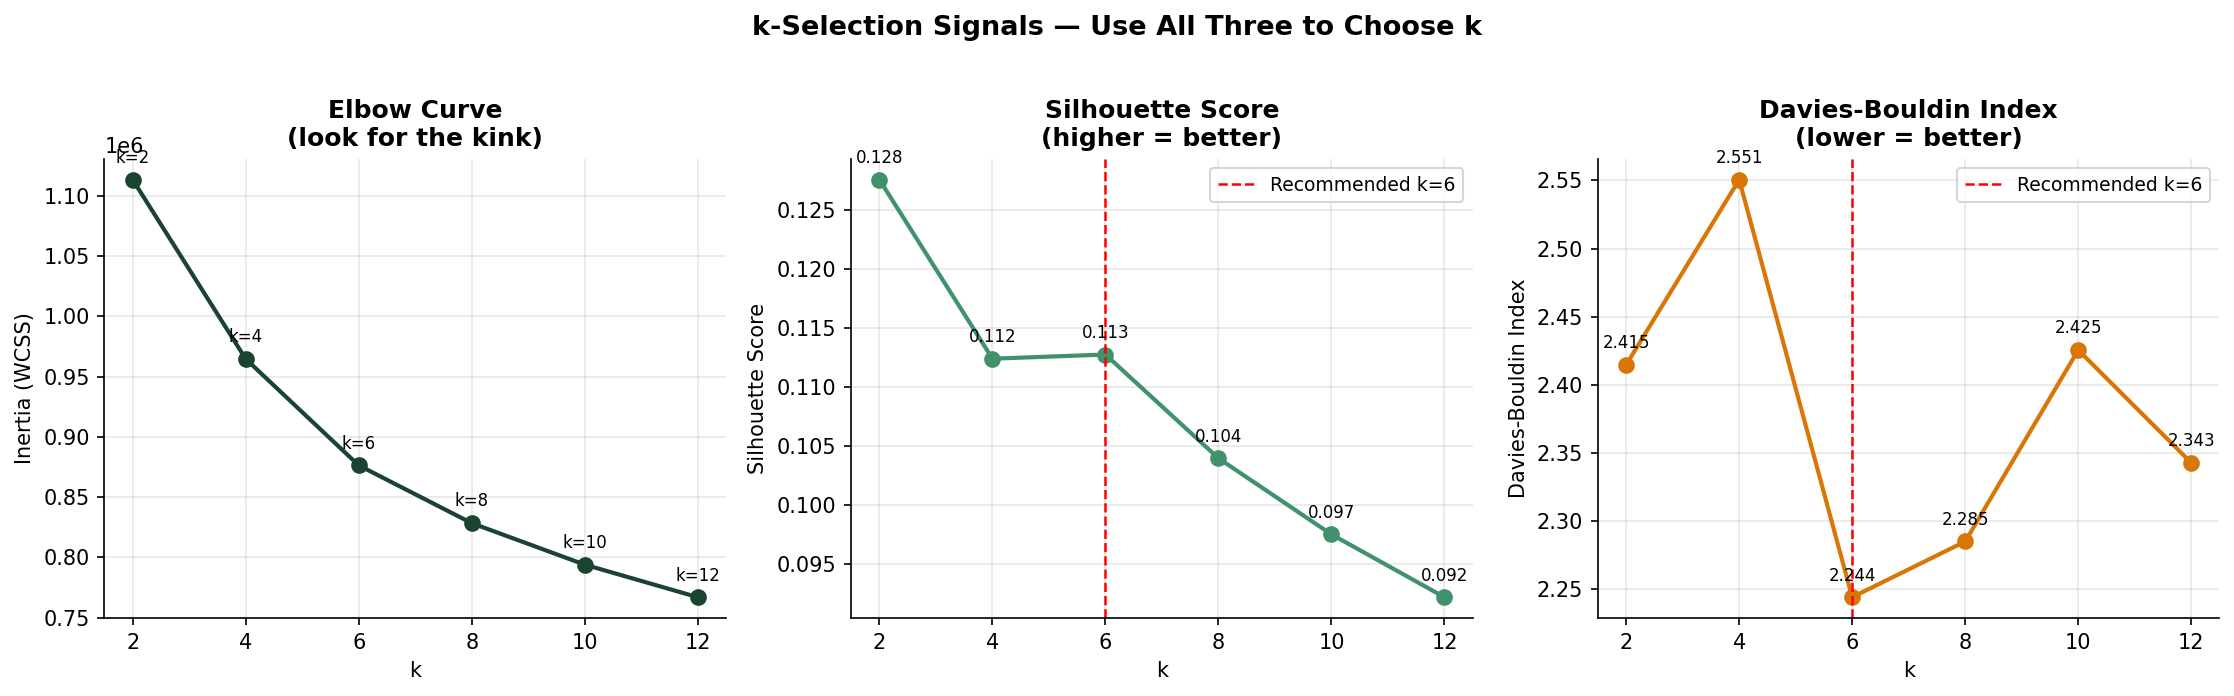

  Saved: clustering/k_selection.png


In [ ]:
print('STEP 1D: k-selection analysis')

# ── Normalise scores to 0–1 for ranking ──────────────────────────
sil_arr = np.array(silhouette_vals)
db_arr  = np.array(db_vals)
ine_arr = np.array(inertia_vals)

sil_norm = (sil_arr - sil_arr.min()) / (sil_arr.ptp() + 1e-9)
db_norm  = 1 - (db_arr  - db_arr.min())  / (db_arr.ptp()  + 1e-9)  # lower DB = better

# Elbow: rate of change of inertia (larger drop = better)
ine_diff  = np.abs(np.diff(ine_arr, prepend=ine_arr[0]))
elbow_norm= (ine_diff - ine_diff.min()) / (ine_diff.ptp() + 1e-9)

combined_score = (sil_norm + db_norm + elbow_norm) / 3

rec_df = pd.DataFrame({
    'k':               S1_K_LIST,
    'inertia':         [round(v,1) for v in inertia_vals],
    'silhouette':      [round(v,4) for v in silhouette_vals],
    'davies_bouldin':  [round(v,4) for v in db_vals],
    'elbow_drop_norm': [round(v,4) for v in elbow_norm],
    'combined_score':  [round(v,4) for v in combined_score],
})
rec_df['rank'] = rec_df['combined_score'].rank(ascending=False).astype(int)
rec_df = rec_df.sort_values('rank').reset_index(drop=True)

rec_csv = os.path.join(S1_DIR_CLUSTER, 'k_recommendation_table.csv')
rec_df.to_csv(rec_csv, index=False)

print('\n  k-Selection Ranked Table (rank 1 = recommended):')
display(rec_df.style
    .background_gradient(subset=['silhouette'], cmap='Greens')
    .background_gradient(subset=['davies_bouldin'], cmap='Reds_r')
    .background_gradient(subset=['combined_score'], cmap='Blues')
    .set_caption('k Recommendation Table — rank 1 = best combined signal')
)

best_k_auto = int(rec_df.iloc[0]['k'])
print(f'\n   Auto-recommended k = {best_k_auto}  (combined Silhouette + DB + Elbow)')
print(f'  ℹ️  Inspect the plots and folders below before accepting this suggestion.')

# ── 3-panel k-selection plot ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
C_LINE = '#1B4332'

axes[0].plot(S1_K_LIST, inertia_vals, 'o-', color=C_LINE, linewidth=2, markersize=7)
for k, v in zip(S1_K_LIST, inertia_vals):
    axes[0].annotate(f'k={k}', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Curve\n(look for the kink)', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(S1_K_LIST, silhouette_vals, 'o-', color='#40916C', linewidth=2, markersize=7)
axes[1].axvline(best_k_auto, color='red', linestyle='--', linewidth=1.2, label=f'Recommended k={best_k_auto}')
for k, v in zip(S1_K_LIST, silhouette_vals):
    axes[1].annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\n(higher = better)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

axes[2].plot(S1_K_LIST, db_vals, 'o-', color='#D97706', linewidth=2, markersize=7)
axes[2].axvline(best_k_auto, color='red', linestyle='--', linewidth=1.2, label=f'Recommended k={best_k_auto}')
for k, v in zip(S1_K_LIST, db_vals):
    axes[2].annotate(f'{v:.3f}', (k, v), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin Index')
axes[2].set_title('Davies-Bouldin Index\n(lower = better)', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle('k-Selection Signals — Use All Three to Choose k', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(S1_DIR_CLUSTER, 'k_selection.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved: clustering/k_selection.png')


### 1E — t-SNE Plots for All k Values


=== STEP 1E: t-SNE visualisation ===
  Running t-SNE (may take a few minutes)...


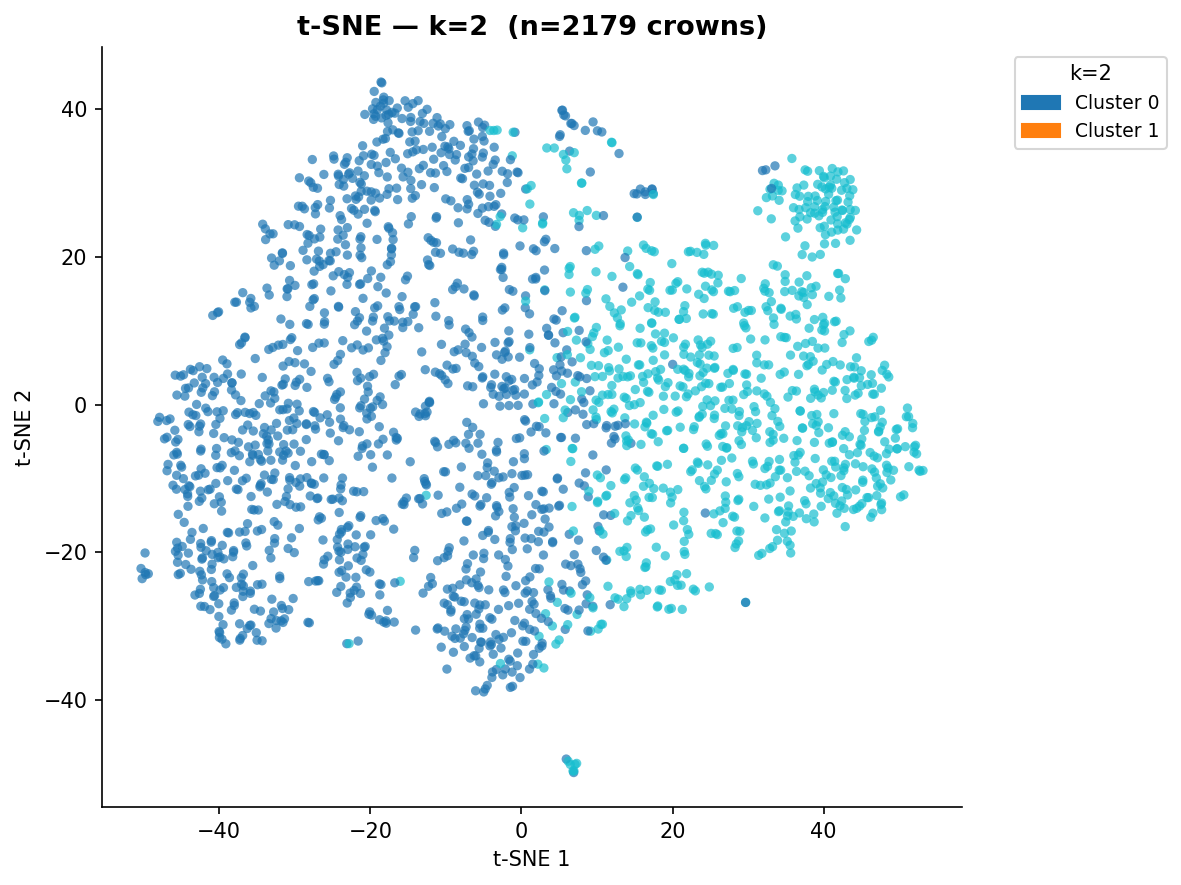

  Saved: tsne_k2.png


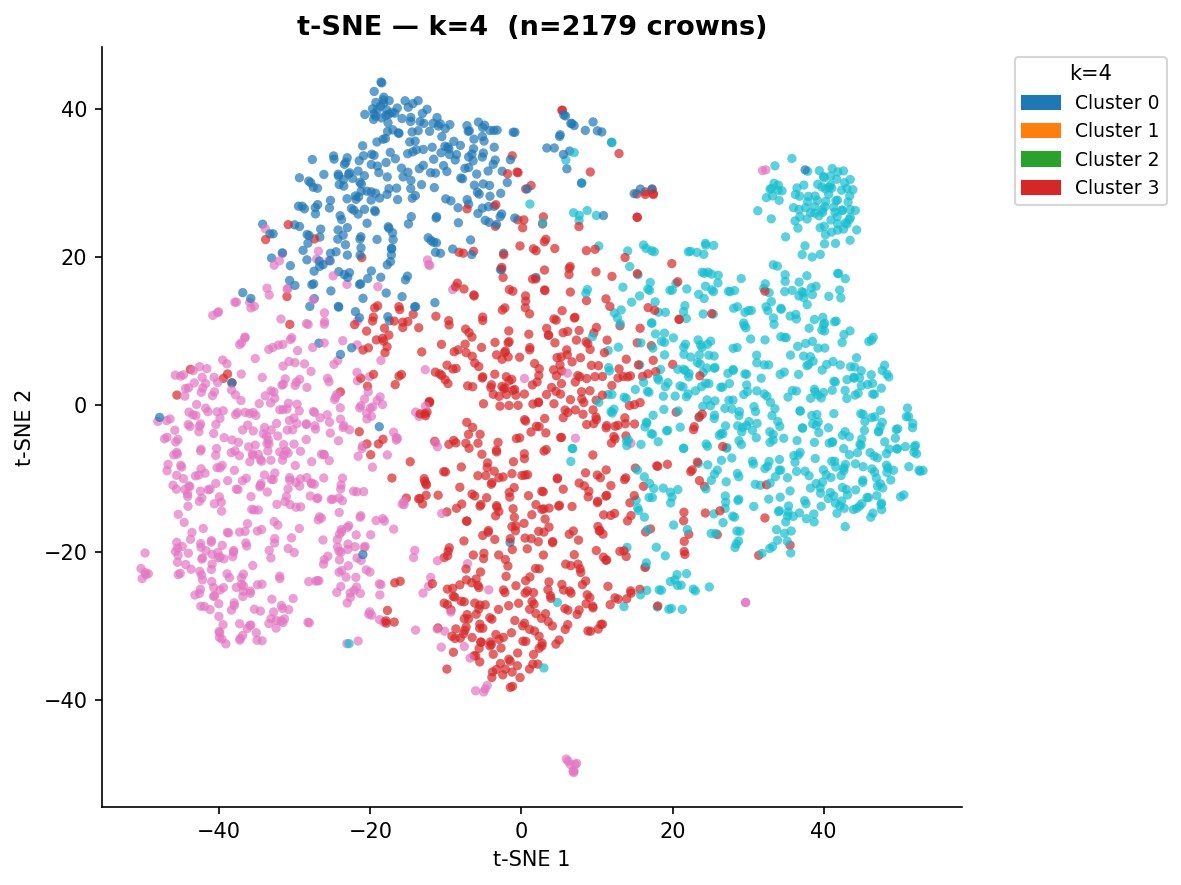

  Saved: tsne_k4.png


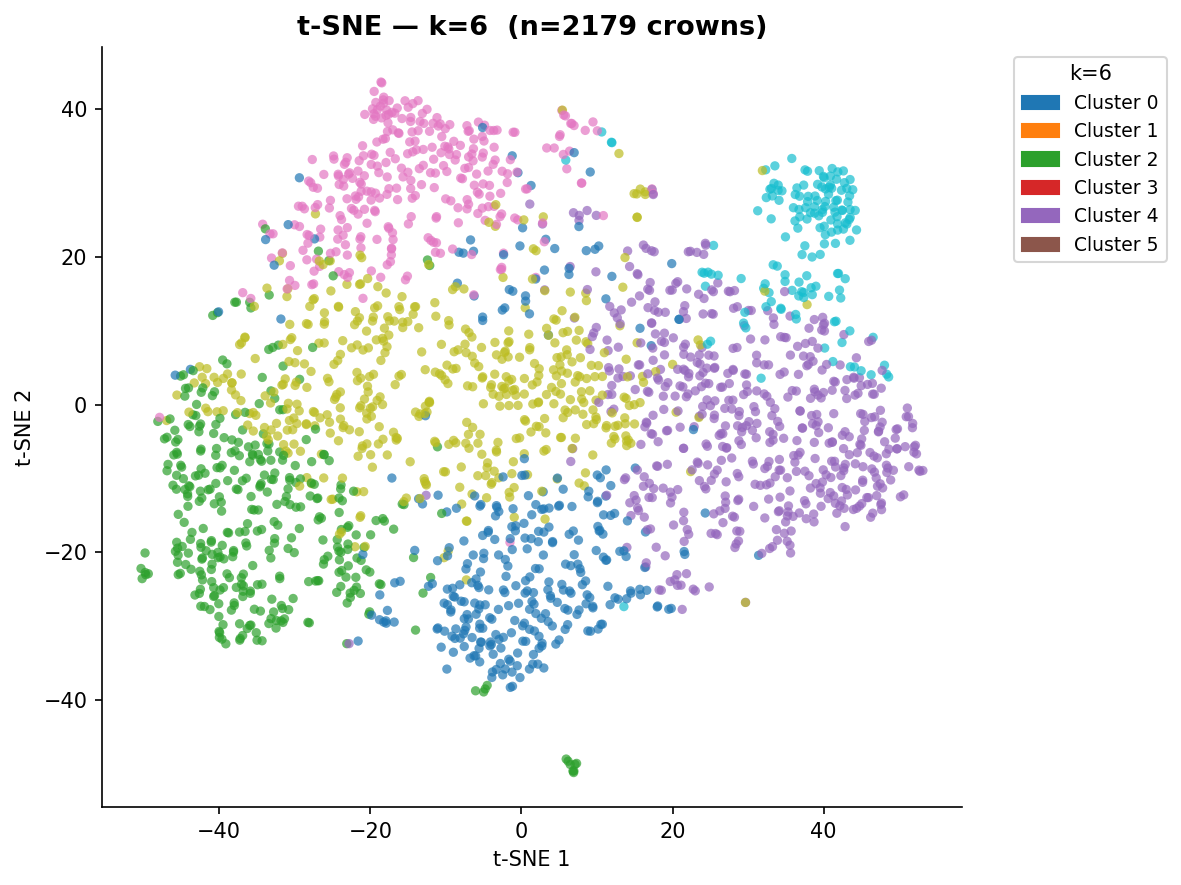

  Saved: tsne_k6.png


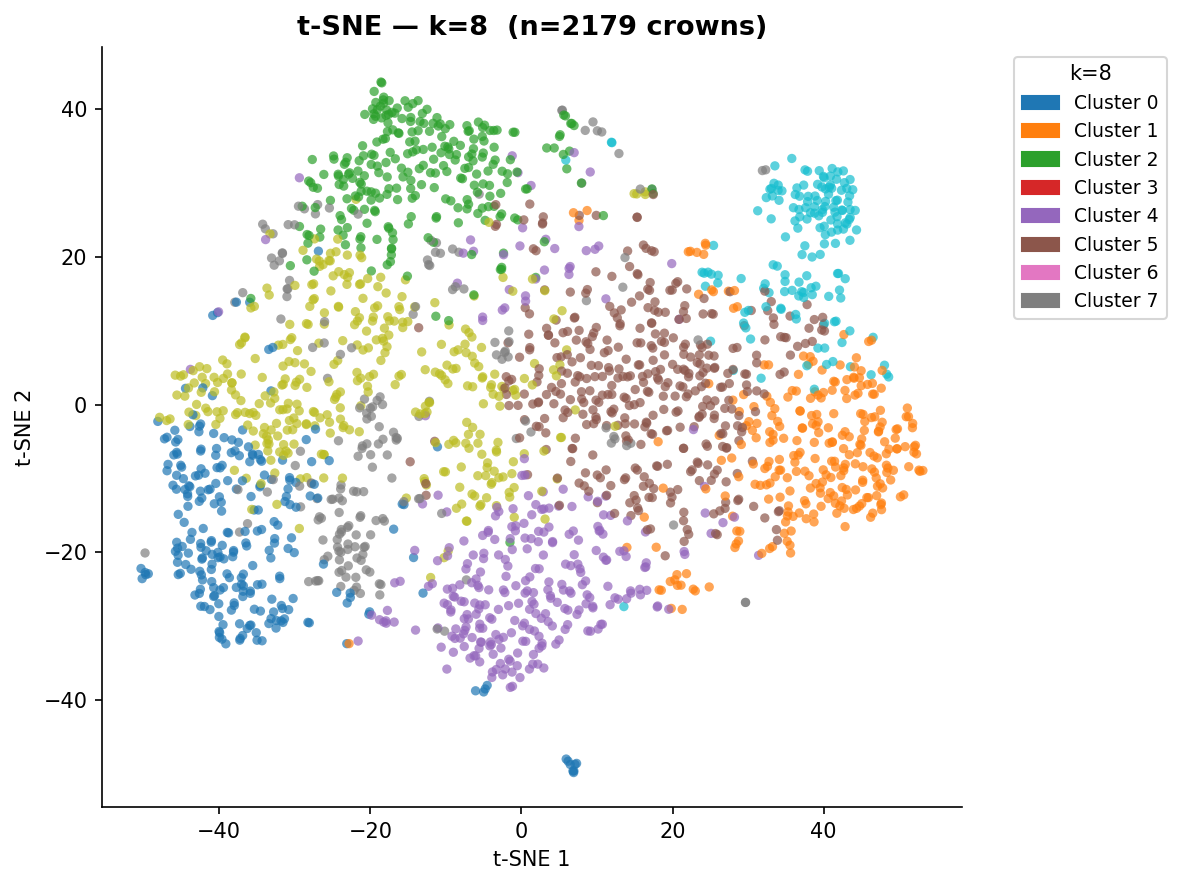

  Saved: tsne_k8.png


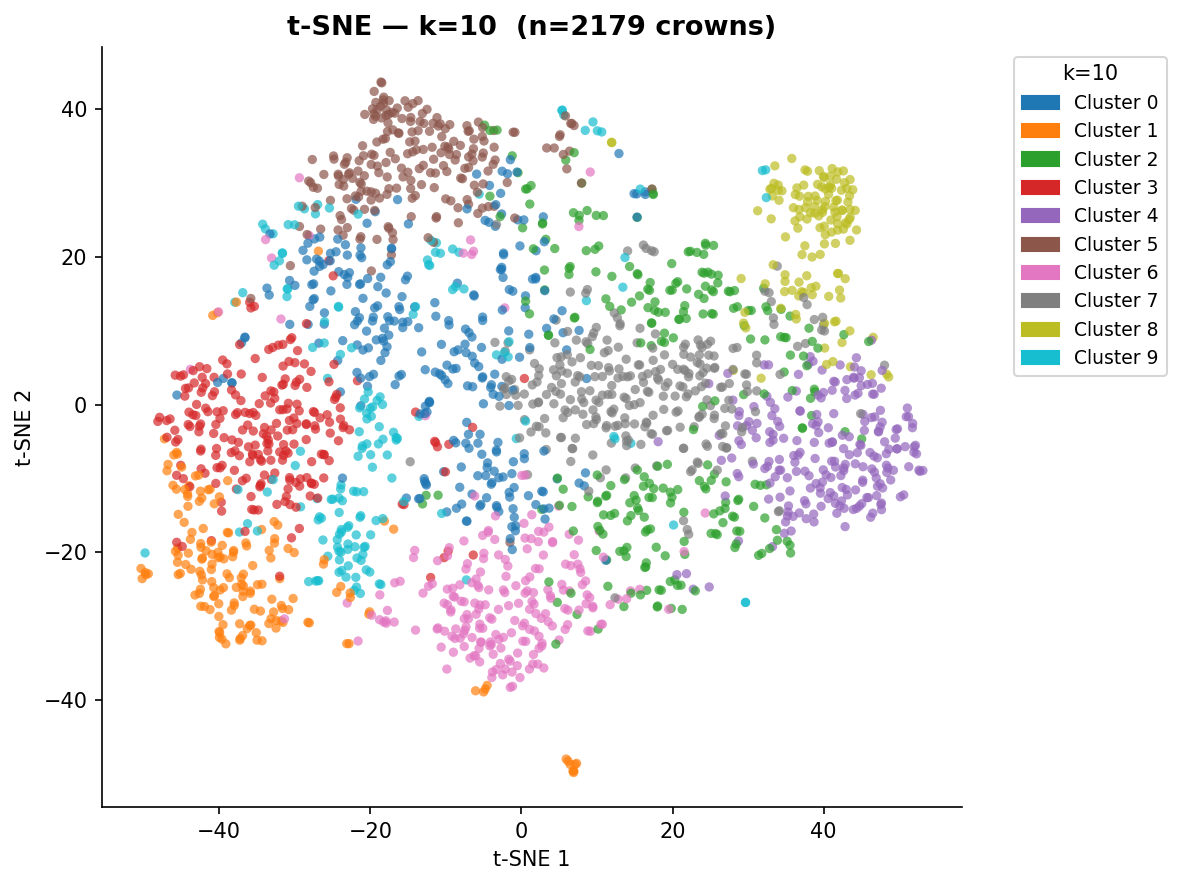

  Saved: tsne_k10.png


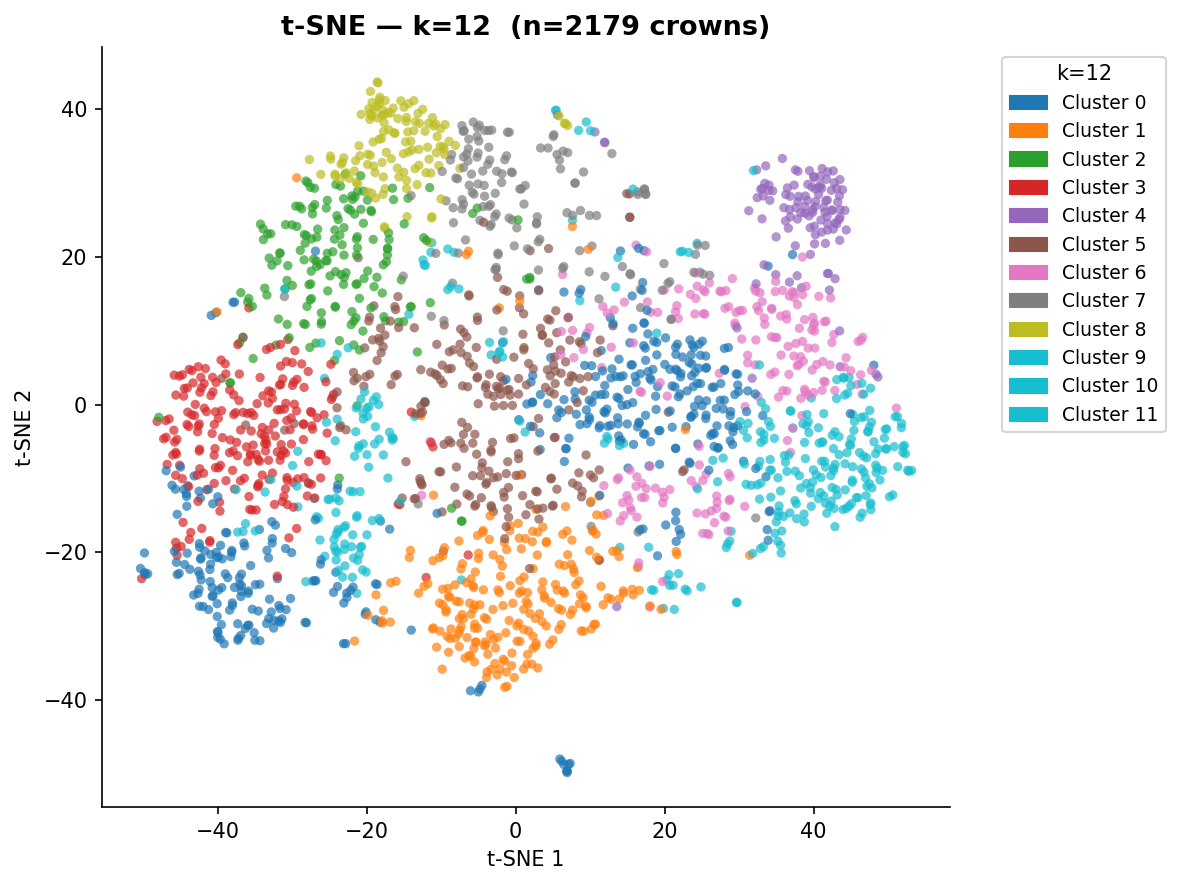

  Saved: tsne_k12.png

✅ Step 1 complete.
   Inspect cluster folders in: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step1_output/clustering
   Then proceed to Step 2 — enter your chosen k and label CSV.


In [ ]:
print('STEP 1E: t-SNE visualisation')
print('  Running t-SNE (may take a few minutes)...')

tsne_coords_path = os.path.join(S1_DIR_CLUSTER, 'tsne_coordinates.csv')
if os.path.exists(tsne_coords_path):
    print('  Cached t-SNE coordinates found — loading.')
    tsne_df = pd.read_csv(tsne_coords_path)
else:
    tsne = TSNE(n_components=2, perplexity=min(30, len(X)-1),
                random_state=42, init='pca', learning_rate='auto')
    X_tsne = tsne.fit_transform(X)
    tsne_df = pd.DataFrame({'x': X_tsne[:,0], 'y': X_tsne[:,1],
                            'image_name': names})
    tsne_df.to_csv(tsne_coords_path, index=False)

for k in S1_K_LIST:
    tsne_df['cluster'] = all_cluster_labels[k]
    fig, ax = plt.subplots(figsize=(8, 6))
    scatter = ax.scatter(tsne_df['x'], tsne_df['y'],
                         c=tsne_df['cluster'], cmap='tab10',
                         s=20, alpha=0.7, linewidths=0)
    handles = [mpatches.Patch(color=plt.cm.tab10(i/10),
                               label=f'Cluster {i}') for i in range(k)]
    ax.legend(handles=handles, bbox_to_anchor=(1.05,1), loc='upper left',
              fontsize=9, title=f'k={k}')
    ax.set_title(f't-SNE — k={k}  (n={len(tsne_df)} crowns)', fontsize=13, fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(S1_DIR_CLUSTER, f'tsne_k{k}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: tsne_k{k}.png')

print('\n Step 1 complete.')
print(f'   Inspect cluster folders in: {S1_DIR_CLUSTER}')
print(f'   Then proceed to Step 2 — enter your chosen k and label CSV.')


---
#  STEP 2 (Scenario 2) — Visual Cluster Labelling → Polygon Species CSV → Species Folders

**Use this when you have NO pre-labeled ground truth images.**

**Workflow:**
1. After Step 1, open `clustering/k{n}/cluster_*/` folders and inspect the crown images visually
2. Open `clustering/k{n}_cluster_species_map.csv` and fill in the `species` column for each cluster
3. Set your chosen k and the filled CSV path below, then run all cells

**Input:**
- Filled `k{n}_cluster_species_map.csv` (cluster → species, user-defined)
- `k{n}_assignments.csv` from Step 1 (image_name → cluster)
- Crown polygon GeoJSON files (same folder as Step 1)

**Output:**
- `polygon_species.csv` — `polygon_id` + `species` only (no image names)
- `species_folders/` — one subfolder per species, crown TIFFs copied inside
- `pseudo_label_assignments.csv` — full table (image_name, cluster, species) for Step 3


### Step 2 — Configuration


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         STEP 2 (SCENARIO 2) — EDIT ONLY THIS BLOCK          ║
# ╚══════════════════════════════════════════════════════════════╝

# ── Chosen k (must match what you filled in the CSV below) ───────
S2_CHOSEN_K = 6          # ← change to your chosen k after Step 1

# ── Path to your filled cluster_species_map CSV ───────────────────
# This file was auto-generated by Step 1 with a blank 'species' column.
# Open it, fill in the species name for each cluster row, save, then run.
# Example row after filling:  cluster=0, species=acacia
S2_CLUSTER_SPECIES_CSV = os.path.join(
    S1_OUTPUT_ROOT, 'clustering',
    f'k{S2_CHOSEN_K}_cluster_species_map.csv'
)  # ← or provide an absolute path if the file is elsewhere

# ── Step 1 output paths (point to same folders Step 1 used) ──────
S2_STEP1_CLUSTER_DIR = os.path.join(S1_OUTPUT_ROOT, 'clustering')
S2_STEP1_CROWNS_DIR  = os.path.join(S1_OUTPUT_ROOT, 'crowns')

# ── GeoJSON polygon folder (same as Step 1) ───────────────────────
# Used to extract polygon IDs and match them to species
S2_POLY_FOLDER = S1_POLY_FOLDER

# ── Output root for Step 2 ────────────────────────────────────────
S2_OUTPUT_ROOT = '/Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output'

# ── Derived paths ─────────────────────────────────────────────────
S2_DIR_SPECIES   = os.path.join(S2_OUTPUT_ROOT, 'species_folders')
make_dirs(S2_DIR_SPECIES, S2_OUTPUT_ROOT)

print(f'Step 2 (Scenario 2) config:')
print(f'  Chosen k              : {S2_CHOSEN_K}')
print(f'  Cluster→species CSV   : {S2_CLUSTER_SPECIES_CSV}')
print(f'  Polygon folder        : {S2_POLY_FOLDER}')
print(f'  Output root           : {S2_OUTPUT_ROOT}')
print(' Config loaded.')


Step 2 (Scenario 2) config:
  Chosen k              : 6
  Cluster→species CSV   : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step1_output/clustering/k6_cluster_species_map.csv
  Polygon folder        : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/geojson
  Output root           : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output
✅ Config loaded.


### 2A — Load Filled Cluster → Species Map


In [ ]:
print('STEP 2A: Loading cluster→species map ')

if not os.path.exists(S2_CLUSTER_SPECIES_CSV):
    raise FileNotFoundError(
        f'CSV not found: {S2_CLUSTER_SPECIES_CSV}\n'
        f'Make sure you have run Step 1 and set S2_CHOSEN_K correctly.'
    )

cluster_map_df = pd.read_csv(S2_CLUSTER_SPECIES_CSV)
print(f'  Loaded: {S2_CLUSTER_SPECIES_CSV}')
print(f'  Rows   : {len(cluster_map_df)}')
print(f'  Columns: {list(cluster_map_df.columns)}')
display(cluster_map_df)

# ── Validate that the user actually filled in species ─────────────
blank_rows = cluster_map_df['species'].isna() | (cluster_map_df['species'].astype(str).str.strip() == '')
if blank_rows.any():
    print(f'\n⚠️  {blank_rows.sum()} cluster(s) still have a blank species:')
    print(cluster_map_df[blank_rows][['cluster','cluster_folder']].to_string(index=False))
    print('   These clusters will be labelled "unlabelled" in the output.')
    print('   Fill them in and re-run if needed.')

# Normalise species names: lowercase, strip, spaces → underscore
cluster_map_df['species'] = (
    cluster_map_df['species']
    .fillna('unlabelled')
    .astype(str).str.strip().str.lower()
    .str.replace(r'[\s\-]+', '_', regex=True)
)

# Build lookup dict:  cluster_int → species_str
cluster_to_species = dict(zip(
    cluster_map_df['cluster'].astype(int),
    cluster_map_df['species']
))

unique_species = sorted(set(v for v in cluster_to_species.values() if v != 'unlabelled'))
print(f'\n  Species defined   : {unique_species}')
print(f'  Cluster mapping   :')
for c, sp in sorted(cluster_to_species.items()):
    print(f'    cluster {c:2d}  →  {sp}')


=== STEP 2A: Loading cluster→species map ===
  Loaded: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step1_output/clustering/k6_cluster_species_map.csv
  Rows   : 6
  Columns: ['cluster', 'cluster_folder', 'species', 'notes']


,cluster,cluster_folder,species,notes
0,0,cluster_0,non-acacia,NaN
1,1,cluster_1,non-acacia,NaN
2,2,cluster_2,acacia,NaN
3,3,cluster_3,non-acacia,NaN
4,4,cluster_4,non-acacia,NaN
5,5,cluster_5,acacia,NaN



  Species defined   : ['acacia', 'non_acacia']
  Cluster mapping   :
    cluster  0  →  non_acacia
    cluster  1  →  non_acacia
    cluster  2  →  acacia
    cluster  3  →  non_acacia
    cluster  4  →  non_acacia
    cluster  5  →  acacia


### 2B — Apply Species Map to All Crown Assignments


In [11]:
print('=== STEP 2B: Applying species labels to all crown assignments ===')

cl_csv = os.path.join(S2_STEP1_CLUSTER_DIR, f'k{S2_CHOSEN_K}_assignments.csv')
if not os.path.exists(cl_csv):
    raise FileNotFoundError(
        f'k{S2_CHOSEN_K}_assignments.csv not found.\n'
        f'Available CSVs in {S2_STEP1_CLUSTER_DIR}:'
        + '\n  ' + '\n  '.join(
            f for f in sorted(os.listdir(S2_STEP1_CLUSTER_DIR))
            if f.endswith('_assignments.csv')
        )
    )

assign_df = pd.read_csv(cl_csv)
assign_df['cluster']  = assign_df['cluster'].astype(int)
assign_df['species']  = assign_df['cluster'].map(cluster_to_species).fillna('unlabelled')

print(f'  Total crown images        : {len(assign_df)}')
print(f'\n  Species distribution:')
sp_counts = assign_df['species'].value_counts()
for sp, n in sp_counts.items():
    print(f'    {sp:<25}: {n:5d}  ({100*n/len(assign_df):.1f}%)')

# Save full assignment table (used by Step 3)
full_assign_path = os.path.join(S2_OUTPUT_ROOT, 'pseudo_label_assignments.csv')
assign_df.to_csv(full_assign_path, index=False)
print(f'\n  Full assignment CSV saved: {full_assign_path}')


=== STEP 2B: Applying species labels to all crown assignments ===
  Total crown images        : 2179

  Species distribution:
    non_acacia               :  1486  (68.2%)
    acacia                   :   693  (31.8%)

  Full assignment CSV saved: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/pseudo_label_assignments.csv


### 2C — Build polygon_species.csv (polygon ID + species, no image names)

Reads the GeoJSON polygon files to extract the canonical polygon ID for each crown,
then joins with the species assignment. Output has **only** `polygon_id` and `species`.


In [ ]:
print(' STEP 2C: Building crown_master.csv + polygon_species.csv ')

# ────────────────────────────────────────────────────────────────────────────
# MASTER CSV strategy:
#   image_name  = filename stem, e.g. s1_tree_006  (universal join key)
#   polygon_id  = original integer id from GeoJSON  (e.g. 6)
#   site        = GeoJSON filename prefix           (e.g. s1)
#   cluster     = K-Means cluster index
#   species     = predicted species label
#
# All downstream steps (Step 3 validation, Step 4 KMZ) join on image_name.
# User ground truth only needs image_name + label — no polygon id required.
# ────────────────────────────────────────────────────────────────────────────

poly_rows = []
for gj_file in sorted(os.listdir(S2_POLY_FOLDER)):
    if not gj_file.endswith('.geojson'):
        continue
    prefix = os.path.splitext(gj_file)[0]   # e.g. 's1'
    gdf_p  = gpd.read_file(os.path.join(S2_POLY_FOLDER, gj_file))

    for idx, row_p in gdf_p.iterrows():
        # ── original polygon id from GeoJSON ─────────────────────
        if 'crown_id' in gdf_p.columns:
            raw_id = row_p['crown_id']
        elif 'id' in gdf_p.columns:
            raw_id = row_p['id']
        else:
            raw_id = idx
        try:
            polygon_id = int(raw_id)
        except (ValueError, TypeError):
            polygon_id = str(raw_id).strip()

        # ── image_name: same convention used in Step 1 cropping ──
        image_name_full = f'{prefix}_{int(raw_id):03d}.tif'   # e.g. s1_000.tif
        image_stem      = os.path.splitext(image_name_full)[0]  # e.g. s1_000

        poly_rows.append({
            'image_name': image_name_full,   # join key — matches GT CSV and Step 1
            'image_stem': image_stem,
            'polygon_id': polygon_id,        # original GeoJSON integer id
            'site':       prefix,
        })

poly_df = pd.DataFrame(poly_rows)

# ── Join species + cluster from Step 2B assign_df ────────────────
poly_df = poly_df.merge(
    assign_df[['image_name', 'cluster', 'species']],
    on='image_name', how='left'
)
poly_df['species'] = poly_df['species'].fillna('unlabelled')
poly_df['cluster'] = poly_df['cluster'].fillna(-1).astype(int)

# ── Save master CSV (all identifiers in one place) ────────────────
master_path = os.path.join(S2_OUTPUT_ROOT, 'crown_master.csv')
poly_df[['image_name', 'image_stem', 'polygon_id', 'site', 'cluster', 'species']]\
    .to_csv(master_path, index=False)

# ── Save polygon_species.csv (polygon_id + species — clean output) ─
poly_csv_path = os.path.join(S2_OUTPUT_ROOT, 'polygon_species.csv')
poly_df[['polygon_id', 'species']].to_csv(poly_csv_path, index=False)

print(f'  Total polygons           : {len(poly_df)}')
print(f'  Matched to species       : {poly_df["species"].ne("unlabelled").sum()}')
print(f'  Unlabelled               : {poly_df["species"].eq("unlabelled").sum()}')
print(f'\n  Files saved:')
print(f'    crown_master.csv       → {master_path}')
print(f'    polygon_species.csv    → {poly_csv_path}')
print(f'\n  crown_master.csv columns: image_name, image_stem, polygon_id, site, cluster, species')
print(f'\n  Preview:')
display(poly_df[['image_name','polygon_id','site','cluster','species']].head(8))


=== STEP 2C: Building crown_master.csv + polygon_species.csv ===
  Total polygons           : 2179
  Matched to species       : 2179
  Unlabelled               : 0

  Files saved:
    crown_master.csv       → /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/crown_master.csv
    polygon_species.csv    → /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/polygon_species.csv

  crown_master.csv columns: image_name, image_stem, polygon_id, site, cluster, species

  Preview:


,image_name,polygon_id,site,cluster,species
0,s1_tree_000.tif,0,s1_tree,5,acacia
1,s1_tree_001.tif,1,s1_tree,4,non_acacia
2,s1_tree_002.tif,2,s1_tree,0,non_acacia
3,s1_tree_003.tif,3,s1_tree,3,non_acacia
4,s1_tree_004.tif,4,s1_tree,0,non_acacia
5,s1_tree_005.tif,5,s1_tree,3,non_acacia
6,s1_tree_006.tif,6,s1_tree,5,acacia
7,s1_tree_007.tif,7,s1_tree,5,acacia


### 2D — Copy Crown TIFFs into Per-Species Folders


In [ ]:
print('STEP 2D: Creating per-species crown folders')

# One subfolder per species
for sp in unique_species + ['unlabelled']:
    os.makedirs(os.path.join(S2_DIR_SPECIES, sp), exist_ok=True)

copied = skipped = 0
for _, row in tqdm(assign_df.iterrows(), total=len(assign_df), desc='Copying TIFFs'):
    sp  = row['species']
    src = os.path.join(S2_STEP1_CROWNS_DIR, row['image_name'])
    dst = os.path.join(S2_DIR_SPECIES, sp, row['image_name'])
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)
        copied += 1
    else:
        skipped += 1

print(f'  Copied : {copied}   Skipped/already-exist: {skipped}')
print(f'\n  Species folders:')
for sp in sorted(os.listdir(S2_DIR_SPECIES)):
    sp_path = os.path.join(S2_DIR_SPECIES, sp)
    if os.path.isdir(sp_path):
        n = len([f for f in os.listdir(sp_path) if f.lower().endswith('.tif')])
        print(f'    species_folders/{sp:<25}: {n} images')

print(f'\n Step 2 (Scenario 2) complete.')
print(f'   Outputs in: {S2_OUTPUT_ROOT}')
print(f'   Files created:')
print(f'     polygon_species.csv           — polygon_id + species (use for analysis / Step 3)')
print(f'     crown_master.csv              — all identifiers + species in one file')
print(f'     pseudo_label_assignments.csv  — full table with image names (internal, for Step 3)')
print(f'     species_folders/              — one subfolder per species with crop TIFFs')
print(f'\n   ➡  Proceed to Step 3 to generate the Google Earth KMZ.')


=== STEP 2D: Creating per-species crown folders ===


Copying TIFFs: 100%|██████████| 2179/2179 [00:02<00:00, 860.74it/s]

  Copied : 2179   Skipped/already-exist: 0

  Species folders:
    species_folders/acacia                   : 693 images
    species_folders/non_acacia               : 1486 images
    species_folders/unlabelled               : 0 images

✅ Step 2 (Scenario 2) complete.
   Outputs in: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output
   Files created:
     polygon_species.csv           — polygon_id + species (use for analysis / Step 3)
     crown_master.csv              — all identifiers + species in one file
     pseudo_label_assignments.csv  — full table with image names (internal, for Step 3)
     species_folders/              — one subfolder per species with crop TIFFs

   ➡  Proceed to Step 3 to generate the Google Earth KMZ.


---
#  STEP 3 (Optional) — Pseudo-Label Validation with Ground Truth

> **This step is completely independent and optional.**
> You can skip directly to Step 4 (Google Earth export) without running this.
> Run it only when you have a set of ground truth labels to compare against.

**What it does:**
- Takes a user-provided ground truth CSV (polygon_id + true species)
- Matches it against the pseudo-label assignments from Step 2
- Produces a confusion matrix, accuracy, F1, and Cohen's kappa
- Saves validation outputs to a separate folder

**Input:**
- Ground truth CSV: `polygon_id` + `true_species` (any column names — auto-detected)
- `polygon_species_full.csv` from Step 2 (generated automatically)

**Output:**
- `step3_validation/confusion_matrix.png`
- `step3_validation/validation_metrics.csv`
- `step3_validation/validation_detail.csv` — per-polygon comparison


### ⚙️ Step 3 — Configuration


In [ ]:
# STEP 3  EDIT ONLY
#  Your ground truth CSV 
# Required columns: image_name (e.g. s1_tree_006.tif) + label/species
# Any column names work — auto-detected.
# Example:
#   image_name,label
#   s1_tree_006.tif,acacia
#   s1_tree_009.tif,non_acacia
S3_GROUND_TRUTH_CSV = '/Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/labels/labeling_sheet.csv'

# ── crown_master.csv from Step 2 (auto-filled if defaults kept) ──
S3_MASTER_CSV       = os.path.join(S2_OUTPUT_ROOT, 'crown_master.csv')

# ── Output folder for validation results ─────────────────────────
S3_VAL_OUTPUT_ROOT  = os.path.join(S2_OUTPUT_ROOT, 'step3_validation')
os.makedirs(S3_VAL_OUTPUT_ROOT, exist_ok=True)

print('Step 3 (Validation) config:')
print(f'  Ground truth CSV  : {S3_GROUND_TRUTH_CSV}')
print(f'  Master CSV        : {S3_MASTER_CSV}')
print(f'  Output folder     : {S3_VAL_OUTPUT_ROOT}')
print(' Config loaded.')


Step 3 (Validation) config:
  Ground truth CSV  : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/labels/labeling_sheet.csv
  Master CSV        : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/crown_master.csv
  Output folder     : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/step3_validation
✅ Config loaded.


### 3A — Load & Match Ground Truth vs Pseudo-Labels


In [ ]:
print(' STEP 3A: Load & match ground truth vs pseudo-labels')

if not os.path.exists(S3_GROUND_TRUTH_CSV):
    raise FileNotFoundError(f'Ground truth CSV not found: {S3_GROUND_TRUTH_CSV}')
if not os.path.exists(S3_MASTER_CSV):
    raise FileNotFoundError(
        f'crown_master.csv not found: {S3_MASTER_CSV}\nRun Step 2 first.'
    )

# ── Load ground truth ─────────────────────────────────────────────
gt_raw = pd.read_csv(S3_GROUND_TRUTH_CSV)
print(f'  Ground truth loaded : {len(gt_raw)} rows')
print(f'  Columns             : {list(gt_raw.columns)}')
display(gt_raw.head(4))

# ── Auto-detect image_name col and label col ──────────────────────
# image_name col: contains .tif / .tiff / _tree_ patterns
# label col:      fewest unique values (most likely species/class)
gt_img_col = gt_label_col = None

for col in gt_raw.columns:
    s = gt_raw[col].dropna().astype(str)
    if s.str.contains(r'\.(tif|tiff)', case=False).mean() > 0.5:
        gt_img_col = col
        break
if gt_img_col is None:
    for col in gt_raw.columns:
        if gt_raw[col].dropna().astype(str).str.contains(r'_tree_', case=False).mean() > 0.3:
            gt_img_col = col
            break
if gt_img_col is None:
    gt_img_col = gt_raw.columns[0]   # fallback: first column

remaining = [c for c in gt_raw.columns if c != gt_img_col]
if remaining:
    gt_label_col = min(remaining, key=lambda c: gt_raw[c].nunique())

print(f'\n  Auto-detected  image_name col = "{gt_img_col}"')
print(f'  Auto-detected  label col      = "{gt_label_col}"')
print('    Override below if wrong:')
# gt_img_col   = 'image_name'
# gt_label_col = 'label'

# ── Build clean GT dataframe ──────────────────────────────────────
gt_df = gt_raw[[gt_img_col, gt_label_col]].copy()
gt_df.columns = ['image_name_raw', 'true_species']

# Normalise image_name: strip path, ensure .tif suffix present
gt_df['image_name'] = (
    gt_df['image_name_raw'].astype(str)
    .apply(lambda x: os.path.basename(x.strip()))
)
# Add .tif if extension missing
gt_df['image_name'] = gt_df['image_name'].apply(
    lambda x: x if x.lower().endswith(('.tif','.tiff')) else x + '.tif'
)

# Normalise species
gt_df['true_species'] = (
    gt_df['true_species'].astype(str).str.strip().str.lower()
    .str.replace(r'[\s\-]+', '_', regex=True)
)

# ── Load crown_master.csv ─────────────────────────────────────────
master_df = pd.read_csv(S3_MASTER_CSV)
master_df['pred_species'] = (
    master_df['species'].astype(str).str.strip().str.lower()
    .str.replace(r'[\s\-]+', '_', regex=True)
)

print(f'\n  crown_master.csv loaded : {len(master_df)} rows')
print(f'  Sample image_names      : {master_df["image_name"].head(3).tolist()}')
print(f'  Sample GT image_names   : {gt_df["image_name"].head(3).tolist()}')

# ── Merge on image_name ───────────────────────────────────────────
val_df = pd.merge(
    gt_df[['image_name', 'true_species']],
    master_df[['image_name', 'pred_species', 'cluster', 'site', 'polygon_id']],
    on='image_name', how='inner'
)

print(f'\n  Ground truth samples : {len(gt_df)}')
print(f'  Master CSV total     : {len(master_df)}')
print(f'  Matched (overlap)    : {len(val_df)}')

if len(val_df) == 0:
    print('\n⚠️  ZERO matches found.')
    print('   Check that image_name values in your ground truth match Step 1 filenames.')
    print(f'   Sample GT names     : {gt_df["image_name"].head(5).tolist()}')
    print(f'   Sample master names : {master_df["image_name"].head(5).tolist()}')
else:
    val_df['correct'] = val_df['true_species'] == val_df['pred_species']
    print(f'\n  Agreement rate       : {val_df["correct"].mean()*100:.1f}%')
    display(val_df.head(8))


=== STEP 3A: Load & match ground truth vs pseudo-labels ===
  Ground truth loaded : 400 rows
  Columns             : ['image_name', 'label']


,image_name,label
0,s1_tree_006.tif,acacia
1,s1_tree_009.tif,acacia
2,s1_tree_013.tif,acacia
3,s1_tree_014.tif,acacia



  Auto-detected  image_name col = "image_name"
  Auto-detected  label col      = "label"
  ⚠️  Override below if wrong:

  crown_master.csv loaded : 2179 rows
  Sample image_names      : ['s1_tree_000.tif', 's1_tree_001.tif', 's1_tree_002.tif']
  Sample GT image_names   : ['s1_tree_006.tif', 's1_tree_009.tif', 's1_tree_013.tif']

  Ground truth samples : 400
  Master CSV total     : 2179
  Matched (overlap)    : 400

  Agreement rate       : 83.8%


,image_name,true_species,pred_species,cluster,site,polygon_id,correct
0,s1_tree_006.tif,acacia,acacia,5,s1_tree,6,True
1,s1_tree_009.tif,acacia,acacia,2,s1_tree,9,True
2,s1_tree_013.tif,acacia,non_acacia,3,s1_tree,13,False
3,s1_tree_014.tif,acacia,non_acacia,4,s1_tree,14,False
4,s1_tree_029.tif,acacia,non_acacia,0,s1_tree,29,False
5,s1_tree_031.tif,non_acacia,non_acacia,1,s1_tree,31,True
6,s1_tree_032.tif,acacia,acacia,2,s1_tree,32,True
7,s1_tree_033.tif,acacia,acacia,2,s1_tree,33,True


### 3B — Confusion Matrix + Metrics


=== STEP 3B: Confusion matrix + metrics ===
  n matched             : 400
  Accuracy              : 83.8%
  Cohen Kappa           : 0.6719
  F1 (macro)            : 0.8336
  F1 (weighted)         : 0.8345

  Classification report:
              precision    recall  f1-score   support

      acacia       0.94      0.71      0.81       193
  non_acacia       0.78      0.96      0.86       207

    accuracy                           0.84       400
   macro avg       0.86      0.83      0.83       400
weighted avg       0.86      0.84      0.83       400



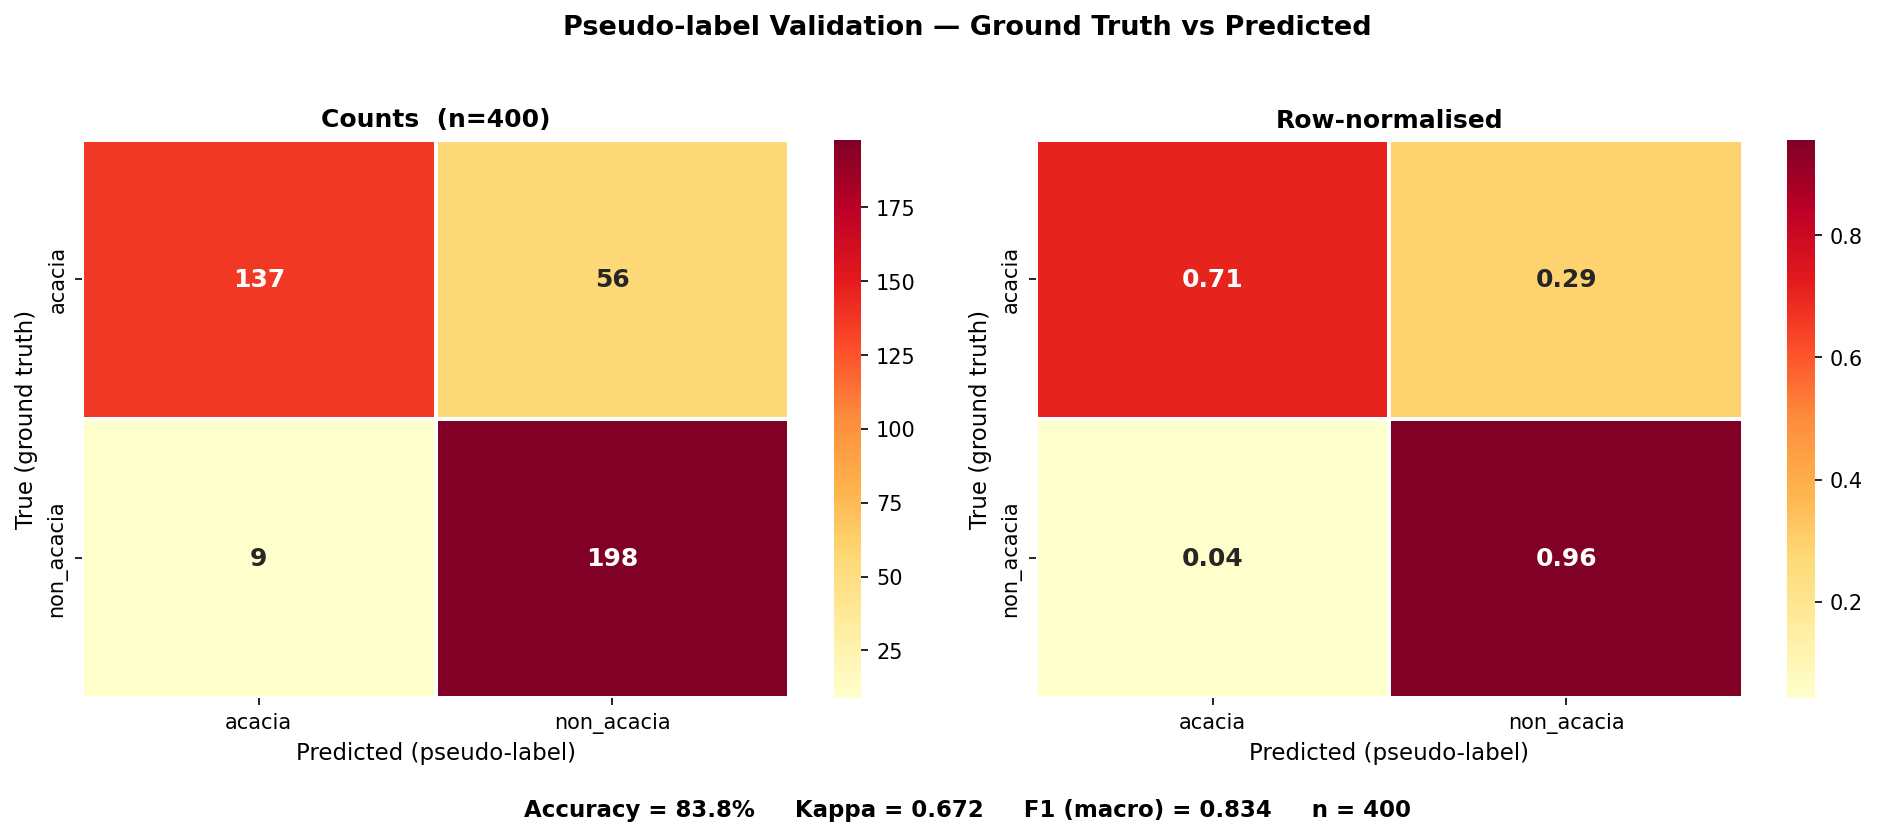

  Saved: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/step3_validation/confusion_matrix.png

  Per-site accuracy:
    s1_tree             : 88.0%  (n=133)
    s2_tree             : 84.8%  (n=138)
    s3_tree             : 72.0%  (n=93)
    s4_tree             : 94.4%  (n=36)

  Saved outputs:
    /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/step3_validation/confusion_matrix.png
    /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/step3_validation/validation_metrics.csv
    /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/step3_validation/validation_detail.csv

✅ Step 3 (Validation) complete.
   ➡  Proceed to Step 4 for Google Earth KMZ export.


In [ ]:
print('STEP 3B: Confusion matrix + metrics ')

if len(val_df) == 0:
    print('No matched samples — skipping. Fix polygon_id mismatch first.')
else:
    from sklearn.metrics import (
        confusion_matrix, classification_report,
        accuracy_score, cohen_kappa_score,
        f1_score, precision_score, recall_score
    )

    y_true   = val_df['true_species']
    y_pred   = val_df['pred_species']
    classes  = sorted(set(y_true.unique()) | set(y_pred.unique()))

    acc      = accuracy_score(y_true, y_pred)
    kappa    = cohen_kappa_score(y_true, y_pred)
    f1_mac   = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    f1_wt    = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # ── Print summary ─────────────────────────────────────────────
    print(f'  n matched             : {len(val_df)}')
    print(f'  Accuracy              : {acc*100:.1f}%')
    print(f'  Cohen Kappa           : {kappa:.4f}')
    print(f'  F1 (macro)            : {f1_mac:.4f}')
    print(f'  F1 (weighted)         : {f1_wt:.4f}')
    print()
    print('  Classification report:')
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

    # ── Confusion matrix heatmap ──────────────────────────────────
    cm      = confusion_matrix(y_true, y_pred, labels=classes)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, title, fmt in [
        (axes[0], cm,      f'Counts  (n={len(val_df)})',   'd'),
        (axes[1], cm_norm, 'Row-normalised',                '0.2f'),
    ]:
        sns.heatmap(
            data, annot=True, fmt=fmt,
            xticklabels=classes, yticklabels=classes,
            cmap='YlOrRd', ax=ax, linewidths=1, linecolor='white',
            annot_kws={'size': 12, 'weight': 'bold'}
        )
        ax.set_xlabel('Predicted (pseudo-label)', fontsize=11)
        ax.set_ylabel('True (ground truth)', fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')

    fig.text(
        0.5, -0.04,
        f'Accuracy = {acc*100:.1f}%     Kappa = {kappa:.3f}     '
        f'F1 (macro) = {f1_mac:.3f}     n = {len(val_df)}',
        ha='center', fontsize=11, fontweight='bold'
    )
    plt.suptitle(
        'Pseudo-label Validation — Ground Truth vs Predicted',
        fontsize=13, fontweight='bold', y=1.03
    )
    plt.tight_layout()
    cm_path = os.path.join(S3_VAL_OUTPUT_ROOT, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {cm_path}')

    # ── Per-site breakdown ────────────────────────────────────────
    if 'site' in val_df.columns:
        print('\n  Per-site accuracy:')
        for site in sorted(val_df['site'].unique()):
            sub = val_df[val_df['site'] == site]
            site_acc = accuracy_score(sub['true_species'], sub['pred_species'])
            print(f'    {site:<20}: {site_acc*100:.1f}%  (n={len(sub)})')

    # ── Save metrics CSV ──────────────────────────────────────────
    metrics_df = pd.DataFrame([{
        'n_matched':    len(val_df),
        'accuracy':     round(acc, 4),
        'cohen_kappa':  round(kappa, 4),
        'f1_macro':     round(f1_mac, 4),
        'f1_weighted':  round(f1_wt, 4),
    }])
    metrics_path = os.path.join(S3_VAL_OUTPUT_ROOT, 'validation_metrics.csv')
    metrics_df.to_csv(metrics_path, index=False)

    # ── Save per-polygon detail ───────────────────────────────────
    detail_path = os.path.join(S3_VAL_OUTPUT_ROOT, 'validation_detail.csv')
    val_df.to_csv(detail_path, index=False)

    print(f'\n  Saved outputs:')
    print(f'    {cm_path}')
    print(f'    {metrics_path}')
    print(f'    {detail_path}')
    print('\n Step 3 (Validation) complete.')
    print('   ➡  Proceed to Step 4 for Google Earth KMZ export.')


---
#  STEP 4 — Species Labels → Google Earth KMZ

**Input:**
- `polygon_species.csv` from Step 2 (polygon_id + species)
- Crown polygon GeoJSON files (same folder as Step 1)

**Output:** `species_map.kmz` — color-coded polygon overlays for Google Earth
- One folder per species with a distinct color
- Popup shows polygon ID, species, and confidence score (if available)
- No orthomosaic overlay (polygons only)


### ⚙️ Step 4 — Configuration


In [ ]:
#   STEP 4 — EDIT ONLY 

# polygon_species CSV from Step 2
S3_POLY_SPECIES_CSV = os.path.join(S2_OUTPUT_ROOT, 'polygon_species.csv')

# Crown polygon GeoJSON folder (same as Step 1)
S3_POLY_FOLDER = S1_POLY_FOLDER

# Output folder for KMZ
S3_OUTPUT_ROOT = '/Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step3_output'

# CRS of your polygon GeoJSONs
# Common: 32643=UTM43N  32644=UTM44N  32642=UTM42N  4326=WGS84
S3_SOURCE_EPSG = 32643

# ── KML colour palette (AABBGGRR hex — KML format) ───────────────
# Add / reorder entries to match your species list.
# Each species gets one color in the order they appear.
S3_COLOR_PALETTE = [
    '990000ff',   # blue
    '9900ff00',   # green
    '99ff0000',   # red
    '9900ffff',   # yellow
    '99ff00ff',   # magenta
    '99ff8800',   # orange
    '9900ffff',   # cyan
    '99ffffff',   # white
]

make_dirs(S3_OUTPUT_ROOT)
print(f'Step 4 config:')
print(f'  polygon_species CSV : {S3_POLY_SPECIES_CSV}')
print(f'  Polygon folder      : {S3_POLY_FOLDER}')
print(f'  Output root         : {S3_OUTPUT_ROOT}')
print(f'  Source EPSG         : {S3_SOURCE_EPSG}')
print(' Config loaded.')


Step 4 config:
  polygon_species CSV : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step2_output/polygon_species.csv
  Polygon folder      : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/geojson
  Output root         : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step3_output
  Source EPSG         : 32643
✅ Config loaded.


### 4A — Load Polygon Species Labels + Merge with Geometries


In [ ]:
print('STEP 4A: Loading polygon species labels')

# ── Load crown_master.csv (has image_name + polygon_id + species) ─
master_path = os.path.join(S2_OUTPUT_ROOT, 'crown_master.csv')
if os.path.exists(master_path):
    master_df_s4 = pd.read_csv(master_path)
    print(f'  crown_master.csv loaded : {len(master_df_s4)} rows')
else:
    # Fallback: load polygon_species.csv (polygon_id + species)
    master_df_s4 = pd.read_csv(S3_POLY_SPECIES_CSV)
    master_df_s4['image_name'] = master_df_s4['polygon_id'].astype(str)
    print(f'  polygon_species.csv loaded (fallback) : {len(master_df_s4)} rows')

# ── Load all GeoJSON polygons ─────────────────────────────────────
all_polys = []
for gj_file in sorted(os.listdir(S3_POLY_FOLDER)):
    if not gj_file.endswith('.geojson'):
        continue
    prefix = os.path.splitext(gj_file)[0]
    g = gpd.read_file(os.path.join(S3_POLY_FOLDER, gj_file))
    g['_cid'] = crown_id_from_gdf(g)
    # Reconstruct image_name the same way Step 1 did — this is the universal key
    g['image_name'] = g['_cid'].apply(lambda x: f'{prefix}_{int(x):03d}.tif')
    if 'Confidence_score' in g.columns:
        g = g.rename(columns={'Confidence_score': 'confidence_score'})
    all_polys.append(g)

gdf_all = pd.concat(all_polys, ignore_index=True)
print(f'  Total polygons loaded : {len(gdf_all)}')

# ── Merge species labels via image_name ───────────────────────────
gdf_all = gdf_all.merge(
    master_df_s4[['image_name', 'species']].rename(columns={'species': 'species'}),
    on='image_name', how='left'
)
gdf_all['species'] = gdf_all['species'].fillna('unlabelled')
print(f'  Labelled polygons     : {gdf_all["species"].ne("unlabelled").sum()}')

# ── Reproject to WGS84 ───────────────────────────────────────────
if gdf_all.crs is None:
    gdf_all = gdf_all.set_crs(epsg=S3_SOURCE_EPSG)
gdf_wgs = gdf_all.to_crs(epsg=4326)
print('  Reprojected to WGS84.')

species_list      = sorted(gdf_wgs['species'].unique())
if 'unlabelled' in species_list:
    species_list.remove('unlabelled')
    species_list.append('unlabelled')

species_color_idx = {sp: i % len(S3_COLOR_PALETTE) for i, sp in enumerate(species_list)}
print(f'\n  Species → colour map:')
for sp, ci in species_color_idx.items():
    print(f'    {sp:<25}: {S3_COLOR_PALETTE[ci]}')


=== STEP 4A: Loading polygon species labels ===
  crown_master.csv loaded : 2179 rows
  Total polygons loaded : 2179
  Labelled polygons     : 2179
  Reprojected to WGS84.

  Species → colour map:
    acacia                   : 990000ff
    non_acacia               : 9900ff00


### 4B — Build KMZ (Species Polygons Only)


In [ ]:
print('STEP 4B: Building KMZ ')

KML_PATH = os.path.join(S3_OUTPUT_ROOT, 'doc.kml')
KMZ_PATH = os.path.join(S3_OUTPUT_ROOT, 'species_map.kmz')

kml = simplekml.Kml()
kml.document.name = 'Tree Crown Species Map'

# One KML folder + style per species
kml_folders = {}
kml_styles  = {}

for sp in species_list:
    ci    = species_color_idx[sp]
    color = S3_COLOR_PALETTE[ci]

    style = simplekml.Style()
    style.polystyle.color   = color
    style.polystyle.fill    = 1
    style.polystyle.outline = 1
    style.linestyle.color   = 'ff000000'
    style.linestyle.width   = 1

    kml_styles[sp]  = style
    folder_name     = sp.replace('_', ' ').title()
    kml_folders[sp] = kml.newfolder(name=folder_name)

added = skipped_geom = 0

for _, row in tqdm(gdf_wgs.iterrows(), total=len(gdf_wgs), desc='Building polygons'):
    geom = row.geometry
    if geom is None or geom.is_empty:
        skipped_geom += 1
        continue
    if geom.geom_type == 'MultiPolygon':
        geom = max(geom.geoms, key=lambda g: g.area)
    if geom.geom_type != 'Polygon':
        skipped_geom += 1
        continue

    sp         = row.get('species', 'unlabelled')
    polygon_id = row.get('polygon_id', '')
    conf       = row.get('confidence_score', '')
    conf_str   = f'{float(conf):.3f}' if pd.notna(conf) and conf != '' else 'N/A'

    folder = kml_folders.get(sp, kml_folders.get('unlabelled'))
    style  = kml_styles.get(sp,  kml_styles.get('unlabelled'))

    pol = folder.newpolygon(
        name=f'{sp} | {polygon_id}',
        outerboundaryis=list(geom.exterior.coords)
    )
    pol.style       = style
    pol.description = (
        f'<b>Polygon ID:</b> {polygon_id}<br>'
        f'<b>Species:</b> {sp}<br>'
        f'<b>Confidence:</b> {conf_str}'
    )
    added += 1

print(f'  Polygons added     : {added}')
print(f'  Skipped (geometry) : {skipped_geom}')

# Save KML + pack KMZ
kml.save(KML_PATH)
with zipfile.ZipFile(KMZ_PATH, 'w', zipfile.ZIP_DEFLATED) as kmz:
    kmz.write(KML_PATH, 'doc.kml')
os.remove(KML_PATH)

size_mb = os.path.getsize(KMZ_PATH) / 1e6
print(f'\n KMZ saved  : {KMZ_PATH}')
print(f'   File size  : {size_mb:.1f} MB')
print(f'   → Open in Google Earth Pro or earth.google.com')


=== STEP 4B: Building KMZ ===


Building polygons: 100%|██████████| 2179/2179 [00:00<00:00, 4716.97it/s]


  Polygons added     : 2179
  Skipped (geometry) : 0

✅ KMZ saved  : /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step3_output/species_map.kmz
   File size  : 0.3 MB
   → Open in Google Earth Pro or earth.google.com


### 4D — Species Distribution Summary


=== STEP 4D: Species distribution summary ===
  Total crown polygons: 2179
    non_acacia               :  1486  (68.2%)
    acacia                   :   693  (31.8%)


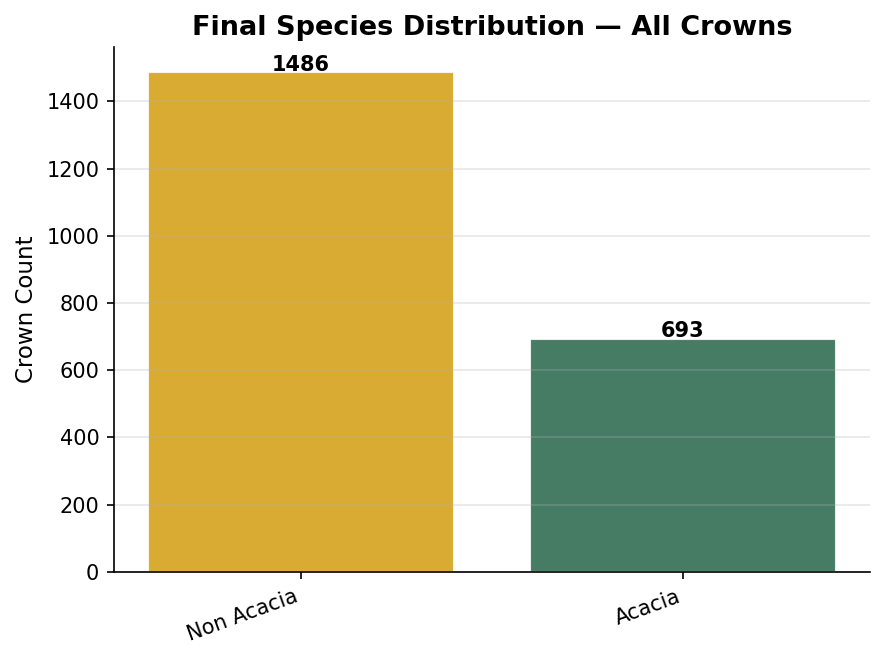

  Saved: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step3_output/species_distribution.png

✅ Step 4 complete. Pipeline (Scenario 2) finished.
   KMZ: /Users/Shared/Files From d.localized/Guide_IITD/data_set_sanjayvan/Data/sanjay_van/Sanjay_Van_Drone/spot1_8_10/final key/step3_output/species_map.kmz


In [ ]:
print('STEP 4D: Species distribution summary')

sp_counts = gdf_wgs['species'].value_counts()
total     = len(gdf_wgs)

print(f'  Total crown polygons: {total}')
for sp, n in sp_counts.items():
    print(f'    {sp:<25}: {n:5d}  ({100*n/total:.1f}%)')

palette = ['#D4A017','#2D6A4F','#2563EB','#7C3AED',
           '#D97706','#0D9488','#DC2626','#888888']
fig, ax = plt.subplots(figsize=(max(6, len(sp_counts)*1.4), 4.5))
bars = ax.bar(range(len(sp_counts)),
              sp_counts.values,
              color=[palette[i % len(palette)] for i in range(len(sp_counts))],
              alpha=0.88, edgecolor='white')
for bar, val in zip(bars, sp_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(val), ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(range(len(sp_counts)))
ax.set_xticklabels([s.replace('_',' ').title() for s in sp_counts.index],
                   rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Crown Count', fontsize=11)
ax.set_title('Final Species Distribution — All Crowns', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
summary_plot = os.path.join(S3_OUTPUT_ROOT, 'species_distribution.png')
plt.savefig(summary_plot, dpi=150, bbox_inches='tight')
plt.show()
print(f'  Saved: {summary_plot}')
print('\n Step 4 complete. Pipeline (Scenario 2) finished.')
print(f'   KMZ: {KMZ_PATH}')
